# Setup

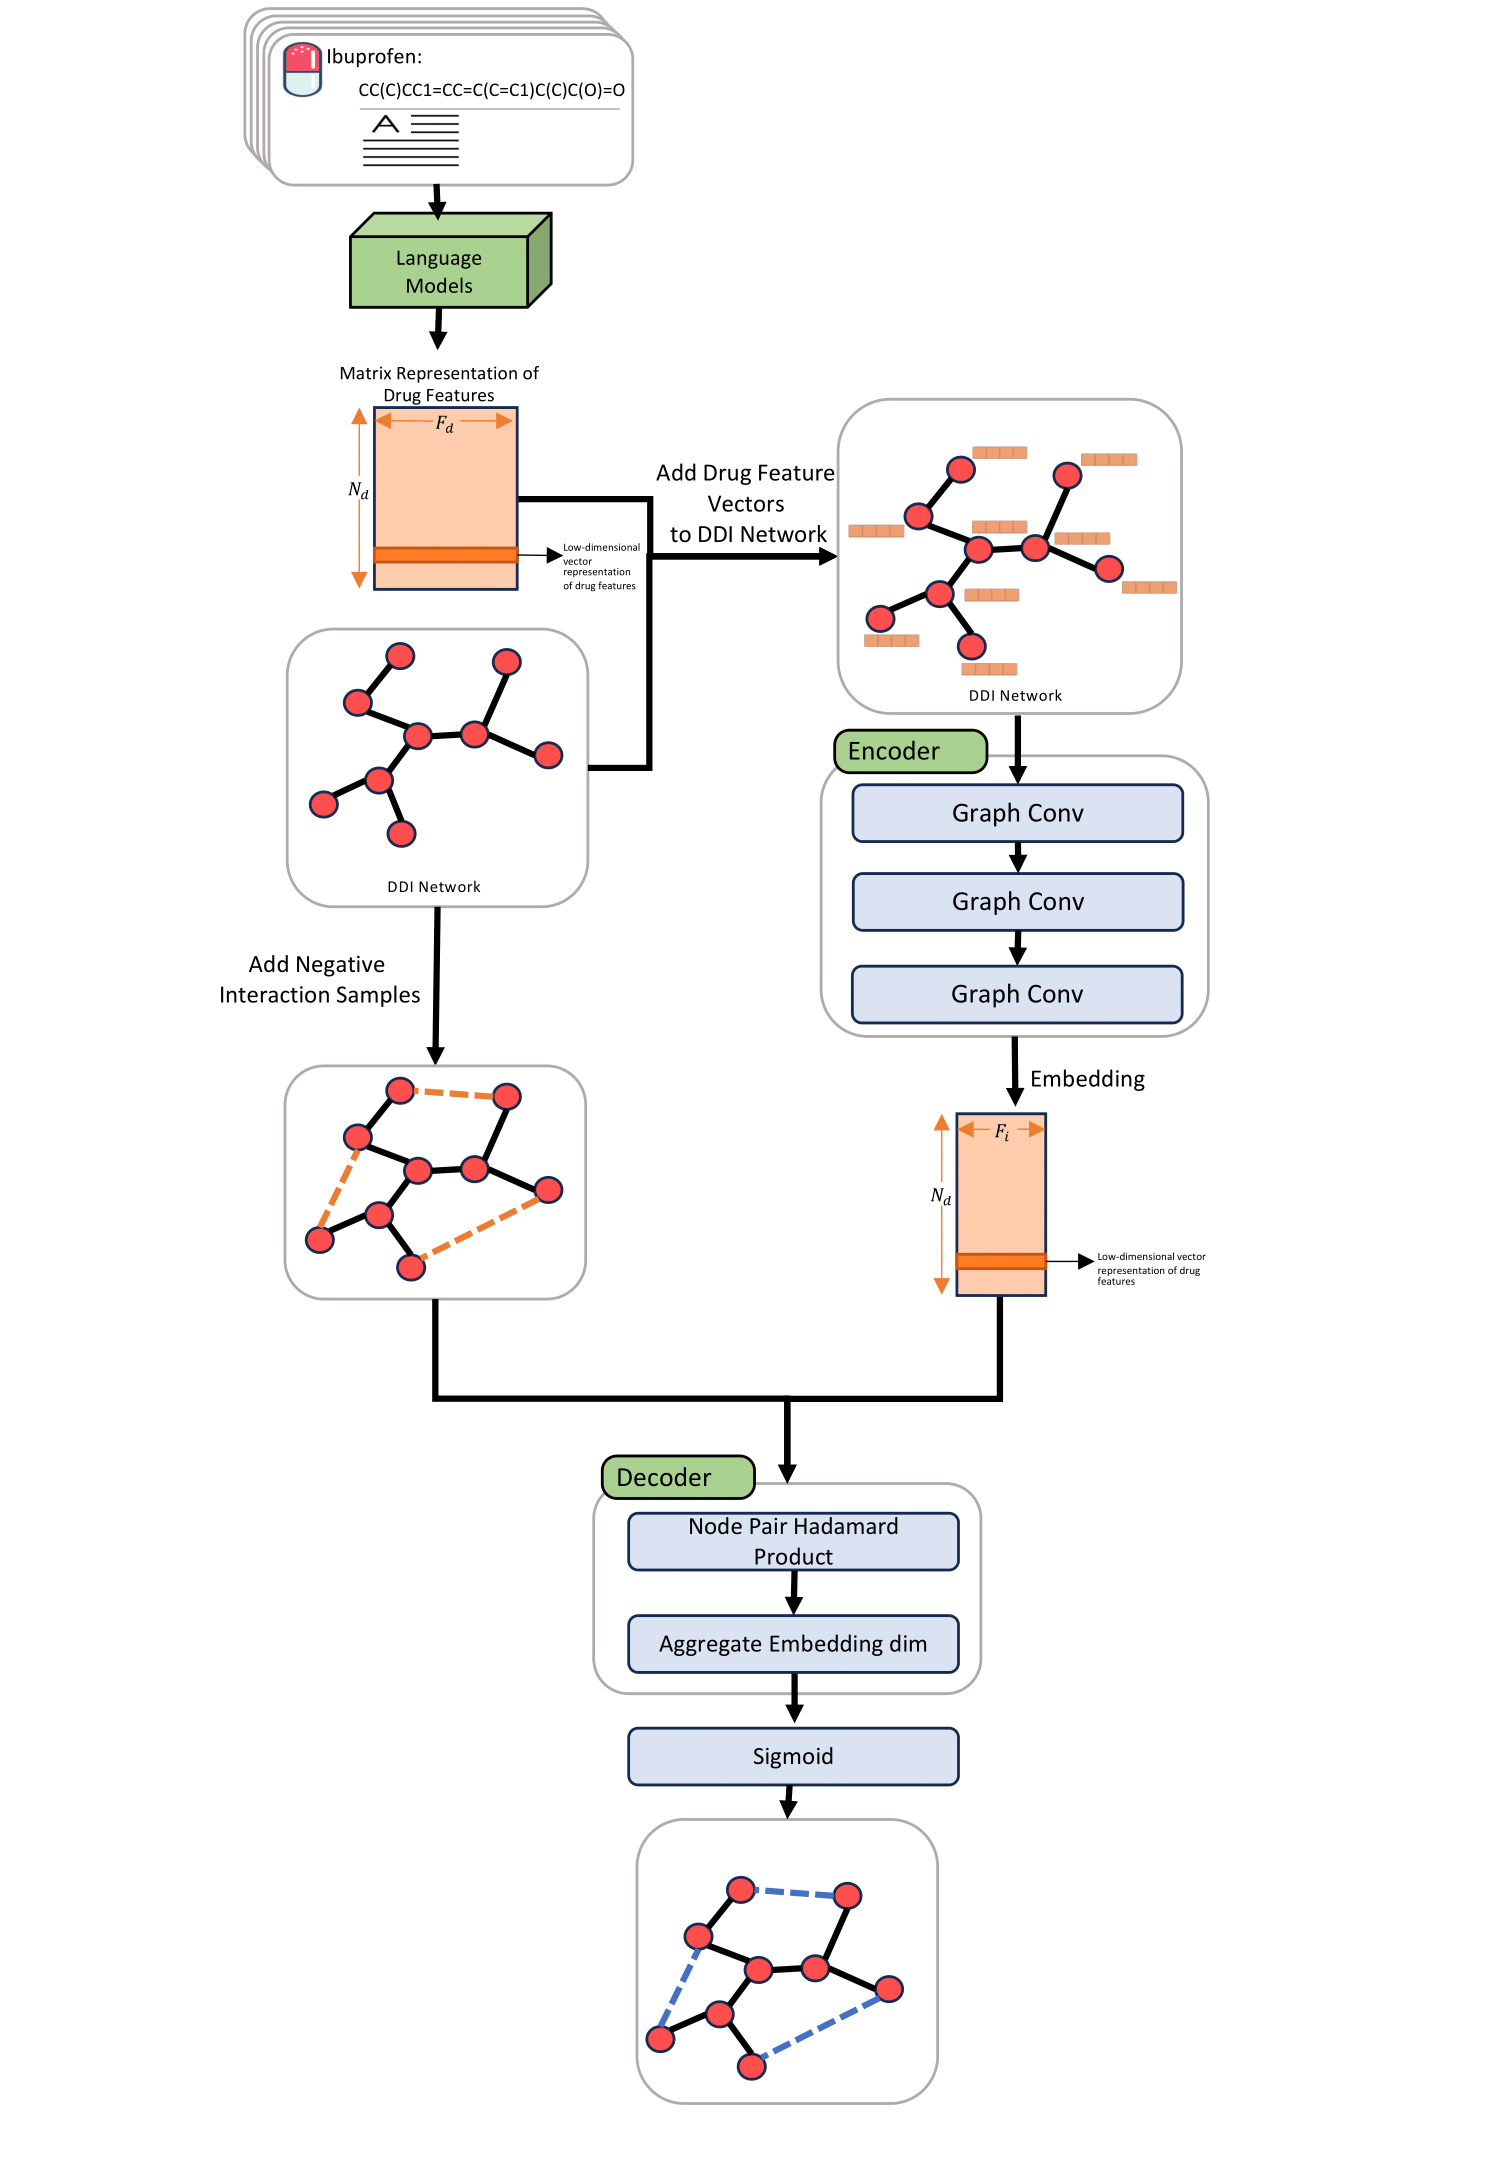

# Experiments

In [12]:
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.manifold import TSNE
from sklearn.metrics import (
    PrecisionRecallDisplay,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    RocCurveDisplay,
    roc_curve,
)

import plotly.express as px

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType


warnings.simplefilter(action="ignore", category=FutureWarning)

## Experiments on Loss

We run three alternative loss configurations on the DrugBank_CRESCENDDI dataset to evaluate how label imbalance handling affects discrimination (ROC) and precision–recall performance (PR).

1. **Binary cross‑entropy with logits (BCEWithLogitsLoss) + negative upsampling.** During training we upsample observed negative examples so that the number of negatives equals the number of positives; the loss is the standard BCE on logits computed on this balanced training set.

2. **Weighted binary cross‑entropy + negative upsampling (pos multiplier = 0.5).** We again upsample negatives but apply a scalar positive‑class multiplier in the loss so that positive examples contribute `pos_loss_multiplier = 0.5` times the loss weight compared to negatives; this re‑weighting was selected because it empirically improved the validation score.

3. **Weighted binary cross‑entropy on observed negatives (no upsampling, pos multiplier = 0.5).** Here we use only the observed negatives (no synthetic upsampling). The imbalance between negatives and positives is therefore reflected directly in the loss by scaling positive examples with the same optimized multiplier (0.5); negatives implicitly receive weight proportional to the observed negative:positive ratio.

Across our experiments the configuration using only observed negatives (setting 3) produced the best generalisation in both ROC and PR metrics, indicating that preserving the empirical negative prevalence while compensating positives via loss weighting is more effective than upsampling negatives in this task.

We also evaluated a focal loss variant. The binary focal loss for a single example can be written as:

$$
\mathrm{FL}(p_t) = -\alpha\,(1 - p_t)^{\gamma}\,\log(p_t)
$$

where $p_t$ is the model probability for the true class, $\alpha$ is a per‑class balancing factor and $\gamma\ge 0$ is the focusing parameter. When $\gamma = 0$ the focal term $(1-p_t)^{\gamma}$ equals $1$ and the focal loss reduces to a (possibly weighted) cross‑entropy; in our hyperparameter search the best focal parameter collapsed to $\gamma \approx 0$, so focal loss offered no additional benefit beyond the weighted BCE formulation.

The following cells run these configurations and collect per‑setting ROC and PR curves, reporting means and standard deviations when repetitions are used.

In [25]:
logging.basicConfig(level=logging.WARNING, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.WARNING)

config = Config()

config.training.seed = 42
config.graph.seed_graph_sampling = 42
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.take_negative_samples = True
config.training.repetitions = 1

## Optimizing individual losses

In [63]:
# find optimal prediction threshold
def find_optimal_threshold(y_true, y_scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

    optimal_idx = f1_scores.argmax()
    current_threshold = thresholds[optimal_idx]
    return current_threshold


def find_balanced_threshold(y_scores):
    """
    Choose a threshold so that the number of predicted positives
    (y_scores >= threshold) is as close as possible to the number
    of predicted negatives (y_scores < threshold).
    """
    y_scores = np.asarray(y_scores).ravel()
    return float(np.median(y_scores))

# print confusion matrix at optimal threshold
def confusion_matrix_at_threshold(y_true, y_scores, current_threshold):
    y_pred = (y_scores >= current_threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    cm_string = "[tn, fp]\n[fn, tp]\n"
    print("Confusion Matrix:")
    print(cm_string)
    print(cm)

def get_f1_at_threshold(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)
    f1 = f1_score(y_true, y_pred)
    return f1

def plot_precision_recall_curve_with_thresholds(y_true, y_scores, current_threshold=None):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    fig, ax = plt.subplots()
    disp = PrecisionRecallDisplay(precision=precisions, recall=recalls)
    disp.plot(ax=ax)
    ax.set_title("Precision-Recall Curve with Thresholds")

    # Plot thresholds as colored points
    norm = plt.Normalize(thresholds.min(), thresholds.max())
    cmap = plt.get_cmap("viridis")
    sc = ax.scatter(recalls[1:], precisions[1:], c=thresholds, cmap=cmap, norm=norm, s=30, label=None)

    cbar = fig.colorbar(sc, ax=ax, label="Threshold")

    # Mark the optimal threshold
    if current_threshold is not None:
        idx = np.argmin(np.abs(thresholds - current_threshold))
        ax.scatter(
            recalls[idx + 1],
            precisions[idx + 1],
            color="red",
            s=80,
            edgecolor="black",
            label=f"Current: {current_threshold:.5f}",
        )
        ax.legend()

    plt.show()
def plot_roc_curve_with_thresholds(y_true, y_scores, current_threshold=None):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fig, ax = plt.subplots()
    disp = RocCurveDisplay(fpr=fpr, tpr=tpr)
    disp.plot(ax=ax)
    ax.set_title("ROC Curve with Thresholds")

    # roc_curve returns thresholds with first value typically = inf; ignore it for coloring/markers
    fpr_plot = fpr[1:]
    tpr_plot = tpr[1:]
    thr_plot = thresholds[1:]
    if thr_plot.size > 0:
        norm = plt.Normalize(thr_plot.min(), thr_plot.max())
        cmap = plt.get_cmap("viridis")
        sc = ax.scatter(fpr_plot, tpr_plot, c=thr_plot, cmap=cmap, norm=norm, s=30, label=None)
        fig.colorbar(sc, ax=ax, label="Threshold")

    # Mark the optimal threshold (if provided)
    if current_threshold is not None and thr_plot.size > 0:
        idx = np.argmin(np.abs(thr_plot - float(current_threshold)))
        ax.scatter(
            fpr_plot[idx],
            tpr_plot[idx],
            color="red",
            s=80,
            edgecolor="black",
            label=f"Current: {float(current_threshold):.5f}",
        )
        ax.legend()

    plt.show()



In [ ]:
settings = [
{
    "loss_type": LossType.BCEWithLogitsLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": False,
},
]

In [65]:
# Set how many repetitions to run for each configuration (adjust as desired)
repetitions = 2  # <- change this to increase/decrease runs per setting

results_list = []
for setting in settings:
    config.run.loss_type = setting["loss_type"]
    config.run.pos_loss_multiplier = setting["pos_loss_multiplier"]
    config.run.upsample_negative_labels = setting["upsample_negative_labels"]
    if "focal_loss_gamma" in setting:
        config.run.focal_loss_gamma = setting["focal_loss_gamma"]

    # apply repetitions to config so `main` will run multiple times and return mean/std metrics
    config.training.repetitions = repetitions

    name = f"{setting['loss_type'].name}|mult={setting['pos_loss_multiplier']}|ups={setting['upsample_negative_labels']}|reps={repetitions}"
    print(f"=== Running: {name} ===")

    run = main(config)

    y_true = np.asarray(run["label"])  # shape (N,)
    y_scores = np.asarray(run["test_scores"])  # shape (N,)
    metrics = run["metrics"]

    # Extract mean/std from metrics (train `main` returns mean/std when repetitions>1)
    roc_mean = metrics.get("AUC_mean", metrics.get("AUC", None))
    roc_std = metrics.get("AUC_std", None)
    pr_mean = metrics.get("PR_AUC_mean", metrics.get("PR_AUC", None))
    pr_std = metrics.get("PR_AUC_std", None)

    precision, recall, pr_thresh = precision_recall_curve(y_true, y_scores)
    fpr, tpr, roc_thresh = roc_curve(y_true, y_scores)

    results_list.append(
        {
            "name": name,
            "setting": setting,
            "metrics": metrics,
            "ROC_AUC_mean": float(roc_mean) if roc_mean is not None else None,
            "ROC_AUC_std": float(roc_std) if roc_std is not None else None,
            "PR_AUC_mean": float(pr_mean) if pr_mean is not None else None,
            "PR_AUC_std": float(pr_std) if pr_std is not None else None,
            "precision": precision,
            "recall": recall,
            "pr_thresh": pr_thresh,
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresh": roc_thresh,
            "y_true": y_true,
            "y_scores": y_scores,
        }
    )

# Expose results for downstream cells
settings_results = results_list

=== Running: BCEWithLogitsLoss|mult=1|ups=True|reps=2 ===
======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6902
PR_AUC: 0.9653
std ROC_AUC: 0.0037
std PR_AUC: 0.0007
repetitions: 2
-------------------------------
=== Running: WeightedBCEWithLogitsLoss|mult=0.5|ups=True|reps=2 ===
======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7480
PR_AUC: 0.9729
std ROC_AUC: 0.0073
std PR_AUC: 0.0006
repetitions: 2
-------------------------------
=== Running: WeightedBCEWithLogitsLoss|mult=0.5|ups=False|reps=2 ===
======== DESC_GPT ========
-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7752
PR_AUC: 0.9763
std ROC_AUC: 0.0072
std PR_AUC: 0.0002
repetitions: 2


In [66]:
# Recreate concise short codes and display legend
from IPython.display import Markdown, display

short_codes = {}
descriptions = []
for i, r in enumerate(settings_results):
    code = f"S{i+1}"
    short_codes[r['name']] = code
    desc = f"{r['setting']['loss_type'].name}, pos_mult={r['setting']['pos_loss_multiplier']}, upsample={r['setting']['upsample_negative_labels']}"
    descriptions.append((code, r['name'], desc))

md = "| Code | Short Name | Details |\n|---|---:|---|\n"
for code, name, desc in descriptions:
    md += f"| **{code}** | `{name}` | {desc} |\n"

display(Markdown("### Settings Legend\n\n" + md))

# Expose mappings for plotting cells
settings_short_codes = short_codes
settings_short_desc = {code: desc for code, _, desc in descriptions}

print('Legend created. Use `settings_short_codes` and `settings_short_desc` in subsequent cells.')

### Settings Legend

| Code | Short Name | Details |
|---|---:|---|
| **S1** | `BCEWithLogitsLoss|mult=1|ups=True|reps=2` | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S2** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=True|reps=2` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S3** | `WeightedBCEWithLogitsLoss|mult=0.5|ups=False|reps=2` | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |
| **S4** | `FocalLoss|mult=1|ups=True|reps=2` | FocalLoss, pos_mult=1, upsample=True |


Legend created. Use `settings_short_codes` and `settings_short_desc` in subsequent cells.


### Settings Legend

| Code | Description |
|---|---|
| **S1** | BCEWithLogitsLoss, pos_mult=1, upsample=True |
| **S2** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=True |
| **S3** | WeightedBCEWithLogitsLoss, pos_mult=0.5, upsample=False |
| **S4** | FocalLoss, pos_mult=1, upsample=True |


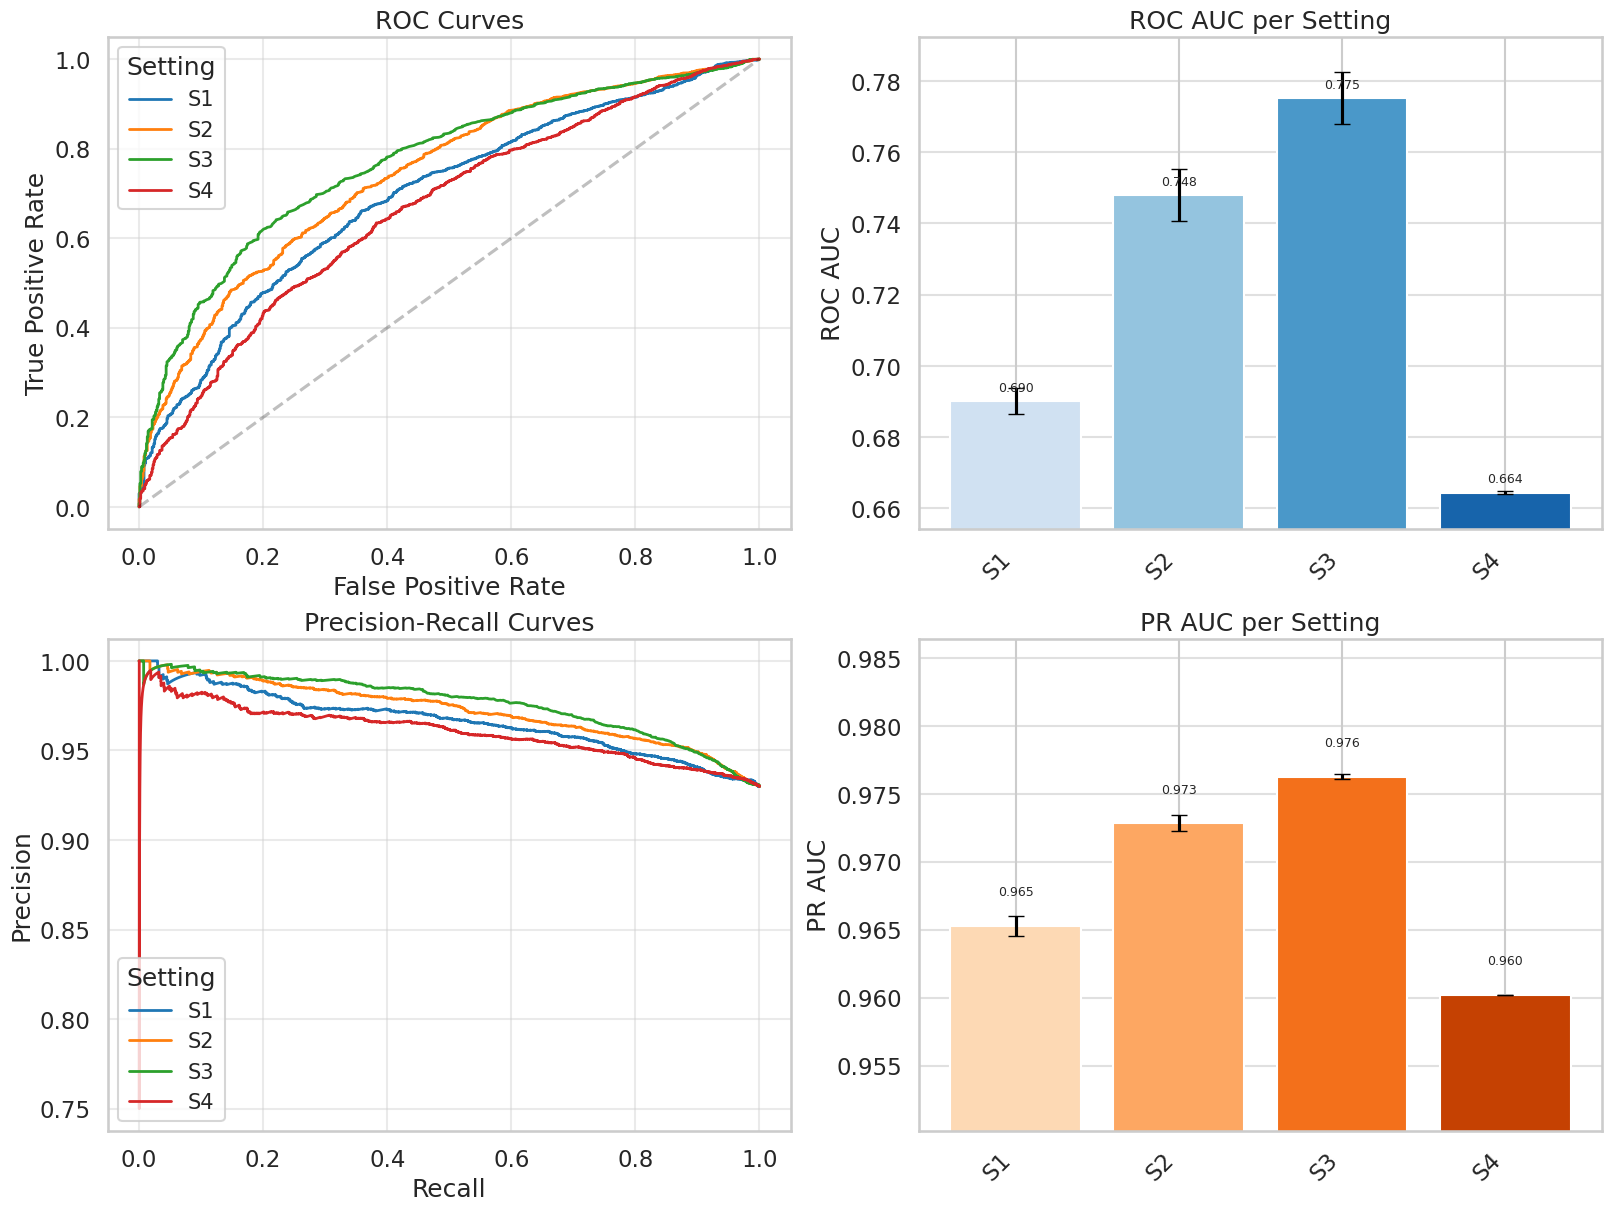

Saved combined report grid to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/report_grid.png
Saved summary CSV to: /home/giobbi/DDI_LLM_repo/DDI_with_ML/analysis/analysis_results_figs/settings_summary.csv


In [67]:
# Consolidated report: 2x2 grid (ROC curves | ROC AUC) / (PR curves | PR AUC)
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import Markdown, display

sns.set_style('whitegrid')
sns.set_context('talk')

# Build summary DataFrame
rows = []
for r in settings_results:
    rows.append(
        {
            "name": r["name"],
            "short": settings_short_codes.get(r["name"], r["name"]),
            "loss_type": r["setting"]["loss_type"].name,
            "pos_loss_multiplier": r["setting"]["pos_loss_multiplier"],
            "upsample_negative_labels": r["setting"]["upsample_negative_labels"],
            "ROC_AUC_mean": r.get("ROC_AUC_mean", np.nan),
            "ROC_AUC_std": r.get("ROC_AUC_std", 0) if r.get("ROC_AUC_std", None) is not None else 0,
            "PR_AUC_mean": r.get("PR_AUC_mean", np.nan),
            "PR_AUC_std": r.get("PR_AUC_std", 0) if r.get("PR_AUC_std", None) is not None else 0,
            "precision": r.get('precision'),
            "recall": r.get('recall'),
            "fpr": r.get('fpr'),
            "tpr": r.get('tpr'),
        }
    )

summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values('short')

# Display concise legend
legend_md = "### Settings Legend\n\n" + "| Code | Description |\n|---|---|\n"
for code, desc in settings_short_desc.items():
    legend_md += f"| **{code}** | {desc} |\n"
display(Markdown(legend_md))

# Create figure directory
fig_dir = os.path.join(os.getcwd(), "analysis_results_figs")
os.makedirs(fig_dir, exist_ok=True)

labels = summary_df['short'].to_list()
indices = np.arange(len(labels))

# Helper to compute y limits with offset
def compute_ylim_with_offset(means, errs=None, min_range=0.03):
    means = np.asarray(means, dtype=float)
    errs = np.zeros_like(means) if errs is None else np.asarray(errs, dtype=float)
    valid = ~np.isnan(means)
    if not valid.any():
        return 0.0, 1.0
    min_val = np.nanmin(means[valid] - errs[valid])
    max_val = np.nanmax(means[valid] + errs[valid])
    data_range = max_val - min_val
    margin = max(0.01, 0.06 * data_range)
    lower = max(0.0, min_val - margin)
    upper = min(1.0, max_val + margin)
    if (upper - lower) < min_range:
        upper = min(1.0, lower + min_range)
        lower = max(0.0, upper - min_range)
    return lower, upper

# Prepare arrays for bars
roc_means = summary_df['ROC_AUC_mean'].to_numpy(dtype=float)
roc_err = summary_df['ROC_AUC_std'].to_numpy(dtype=float)
pr_means = summary_df['PR_AUC_mean'].to_numpy(dtype=float)
pr_err = summary_df['PR_AUC_std'].to_numpy(dtype=float)

roc_low, roc_hi = compute_ylim_with_offset(roc_means, roc_err)
pr_low, pr_hi = compute_ylim_with_offset(pr_means, pr_err)

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
(ax_roc_curve, ax_roc_bar), (ax_pr_curve, ax_pr_bar) = axes

# Top-left: ROC curves (no numeric values in legend)
for _, row in summary_df.iterrows():
    short = row['short']
    mask = [r for r in settings_results if settings_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_roc_curve.plot(r['fpr'], r['tpr'], label=short, linewidth=2)
ax_roc_curve.plot([0,1],[0,1],'k--', alpha=0.25)
ax_roc_curve.set_title('ROC Curves')
ax_roc_curve.set_xlabel('False Positive Rate')
ax_roc_curve.set_ylabel('True Positive Rate')
ax_roc_curve.grid(alpha=0.4)
ax_roc_curve.legend(title='Setting', fontsize='small')

# Top-right: ROC AUC bar
bars_roc = ax_roc_bar.bar(indices, roc_means, yerr=roc_err, capsize=6, color=sns.color_palette('Blues', n_colors=len(labels)))
ax_roc_bar.set_xticks(indices)
ax_roc_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_roc_bar.set_ylim(roc_low, roc_hi)
ax_roc_bar.set_title('ROC AUC per Setting')
ax_roc_bar.set_ylabel('ROC AUC')
ax_roc_bar.grid(axis='y', alpha=0.6)
for rect in bars_roc:
    h = rect.get_height()
    ax_roc_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

# Bottom-left: Precision-Recall curves (no numeric values in legend)
for _, row in summary_df.iterrows():
    short = row['short']
    mask = [r for r in settings_results if settings_short_codes.get(r['name']) == short]
    if mask:
        r = mask[0]
        ax_pr_curve.plot(r['recall'], r['precision'], label=short, linewidth=2)
ax_pr_curve.set_title('Precision-Recall Curves')
ax_pr_curve.set_xlabel('Recall')
ax_pr_curve.set_ylabel('Precision')
ax_pr_curve.grid(alpha=0.4)
ax_pr_curve.legend(title='Setting', fontsize='small', loc='lower left')

# Bottom-right: PR AUC bar
bars_pr = ax_pr_bar.bar(indices, pr_means, yerr=pr_err, capsize=6, color=sns.color_palette('Oranges', n_colors=len(labels)))
ax_pr_bar.set_xticks(indices)
ax_pr_bar.set_xticklabels(labels, rotation=45, ha='right')
ax_pr_bar.set_ylim(pr_low, pr_hi)
ax_pr_bar.set_title('PR AUC per Setting')
ax_pr_bar.set_ylabel('PR AUC')
ax_pr_bar.grid(axis='y', alpha=0.6)
for rect in bars_pr:
    h = rect.get_height()
    ax_pr_bar.text(rect.get_x() + rect.get_width()/2., h + 0.002, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

# Save combined report figure
report_path = os.path.join(fig_dir, 'report_grid.png')
fig.savefig(report_path, dpi=180)
plt.show()
print(f"Saved combined report grid to: {report_path}")

# Also save summary CSV
summary_csv = os.path.join(fig_dir, 'settings_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print(f"Saved summary CSV to: {summary_csv}")


## Experiments on Datasets

In [9]:
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")
logging.getLogger().setLevel(logging.DEBUG)

config = Config()


config.training.seed = 42
config.graph.seed_graph_sampling = 42
config.graph.current_graph = "DrugBank_CRESCENDDI"
config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
config.run.pos_loss_multiplier = 0.5
config.training.repetitions = 1



In [10]:
run = main(config)
logging.getLogger().setLevel(logging.WARNING)

run['metrics']

2026-04-10 16:51:25,471 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-04-10 16:51:28,265 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-10 16:51:28,327 - DEBUG - Taking only positive samples. 
Dropped negative edges: 3784, 

2026-04-10 16:51:28,330 - DEBUG - Final graph has 1516 nodes and 50108 edges.
Positive edges: 50108, 
Negative edges: 0
2026-04-10 16:51:28,331 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-10 16:51:28,333 - DEBUG - No negative edges in the graph data. Sampling 50108 negative edges.


======== DESC_GPT ========


2026-04-10 16:51:28,543 - DEBUG - Using imbalanced loss with pos_weight: 0.4850
2026-04-10 16:51:38,680 - DEBUG - Early stopping at epoch 22


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.8784
PR_AUC: 0.8521


{'AUC_mean': 0.8783568825394822,
 'AUC_std': 0.0,
 'PR_AUC_mean': 0.8520618079807067,
 'PR_AUC_std': 0.0,
 'repetitions': 1}

# Experiment of Embeddings